### 1-3. 함수와 그래프: 예측 모델의 직관적 이해

#### 🎯 학습 목표

이번 시간을 통해 우리는 다음을 할 수 있게 됩니다.

  * **함수의 기본 개념 이해**: AI 모델의 예측 과정을 '입력(Input) → 처리(Process) → 출력(Output)'의 함수 관계로 설명할 수 있습니다.
  * **그래프의 시각적 이해**: 선형, 지수, 로그, 시그모이드 함수의 그래프 형태를 보고, 각 함수가 어떤 데이터 관계를 표현하는지 직관적으로 파악할 수 있습니다.
  * **헬스케어 예시 적용**: Python 코드로 각 함수를 직접 그려보고, 실제 헬스케어 AI 시나리오에서 어떻게 활용되는지 구체적인 예시를 들어 설명할 수 있습니다.
  * **그래프 해석 능력**: 그려진 그래프를 보고 데이터의 숨겨진 패턴과 인사이트를 도출할 수 있습니다.

-----

### ⚙️ 핵심 개념: 함수는 AI의 '예측 레시피'

함수(Function)란 입력값을 받아 정해진 규칙에 따라 계산한 뒤, 결과(출력값)를 내놓는 '처리 상자'와 같습니다. 그래프(Graph)는 이러한 입출력 관계를 '눈'으로 볼 수 있게 하여, AI가 데이터 속에서 어떤 패턴을 학습했는지 직관적으로 이해하게 돕습니다.

실습 환경 설정
모든 실습에 앞서, 계산을 위한 `numpy`와 그래프를 그리기 위한 `matplotlib` 라이브러리를 불러옵니다.

# **↓↓그래프에서 한글이 깨지는걸 방지하기 위해 아래 코드를 반드시 실행 후 실습을 진행해주세요↓↓**

In [11]:
# ── Matplotlib 한글 폰트(나눔고딕) 설정: Google Colab 기준 ─────────────────────────

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1) 나눔 폰트 설치 (Colab 전용 명령)
!apt-get update -qq
!apt-get install -qq fonts-nanum*

!brew tap homebrew/cask-fonts
!brew install --cask font-nanum-gothic

# 2) 폰트 등록: 파일 경로와 폰트 이름 매핑
fe = fm.FontEntry(
    fname="/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    name="NanumGothic"
)
fm.fontManager.ttflist.insert(0, fe)  # 폰트 목록 최상단에 삽입

# 3) Matplotlib 전역 설정
plt.rcParams.update({
    "font.size": 10,
    "font.family": "NanumGothic"
})
mpl.rcParams["axes.unicode_minus"] = False  # 음수 기호 깨짐 방지

# (선택) 정상 적용 확인
# from matplotlib.font_manager import FontProperties
# print("Resolved font path:", fm.findfont(FontProperties(family="NanumGothic")))


zsh:1: command not found: apt-get
zsh:1: no matches found: fonts-nanum*
Error: homebrew/cask-fonts was deprecated. This tap is now empty and all its contents were either deleted or migrated.
==> Upgrading 1 outdated package:
font-nanum-gothic latest -> latest
==> Upgrading font-nanum-gothic
==> Cloning https://github.com/google/fonts.git
Updating /Users/admin/Library/Caches/Homebrew/Cask/fonts.git--git-sparse
==> Checking out branch main
Already on 'main'
Your branch is up to date with 'origin/main'.
HEAD is now at 198764c0 Merge pull request #9912 from google/thomasphinney
==> Backing Font 'NanumGothic-Bold.ttf' up to '/opt/homebrew/Caskroom/font-nanum
==> Removing Font '/Users/admin/Library/Fonts/NanumGothic-Bold.ttf'
==> Backing Font 'NanumGothic-ExtraBold.ttf' up to '/opt/homebrew/Caskroom/font-
==> Removing Font '/Users/admin/Library/Fonts/NanumGothic-ExtraBold.ttf'
==> Backing Font 'NanumGothic-Regular.ttf' up to '/opt/homebrew/Caskroom/font-na
==> Removing Font '/Users/admin/Lib

### **1. 선형 함수 (Linear Function): 꾸준한 비례 관계**

  * **공식**: $y = ax + b$
  * **그래프 모양**: 끝없이 이어지는 **직선**.
  * **헬스케어 예시**: **수면 시간과 스트레스 지수 감소량**

[Image of a linear function graph]

#### **💡 Insight & 그래프 해석**

그래프가 **직선**이라는 것은 **변화율이 일정하다**는 의미입니다. 즉, "수면을 1시간 더 잘 때마다 스트레스 지수는 항상 5포인트씩 감소한다"처럼 원인과 결과가 정직하게 비례합니다. 직선의 기울기(a)는 그 효과의 크기를 나타냅니다. 기울기가 가파를수록 적은 수면 시간으로도 큰 스트레스 감소 효과를 본다는 의미입니다.



#### **💻 파이썬 실습**

##### **🛠️ 사용 방법 및 주요 함수/옵션 안내**

  * **NumPy `np.linspace(start, stop, num)`**: `start`부터 `stop`까지의 구간을 `num`개의 일정한 간격으로 나눈 숫자 배열을 생성합니다. 그래프의 x축 데이터를 부드럽게 만드는 데 유용합니다.

In [14]:
# 0부터 10까지 5개의 점으로 나눈 배열 생성
x_points = np.linspace(0, 10, 5)
print(x_points) # 출력: [ 0.   2.5  5.   7.5 10. ]

[ 0.   2.5  5.   7.5 10. ]


* **Matplotlib `plt.plot()` 주요 옵션**:
      * `color`: 선의 색상을 지정합니다. (`'blue'`, `'red'`, `'green'`, `'#FFDD00'` 등)
      * `linewidth`: 선의 두께를 조절합니다.
      * `linestyle`: 선의 스타일을 지정합니다. (`'-'` (실선), `'--'` (파선), `':'` (점선))
      * `label`: 그래프의 범례(legend)에 표시될 이름을 지정합니다. (이후 `plt.legend()` 함수 필요)

##### **예제: 수면 시간에 따른 스트레스 감소량 시각화**

하루 수면 시간을 1시간부터 10시간까지 가정하고, "수면 1시간당 스트레스 지수 5 감소" 모델을 그래프로 그려봅니다. (기본 스트레스 100에서 시작)

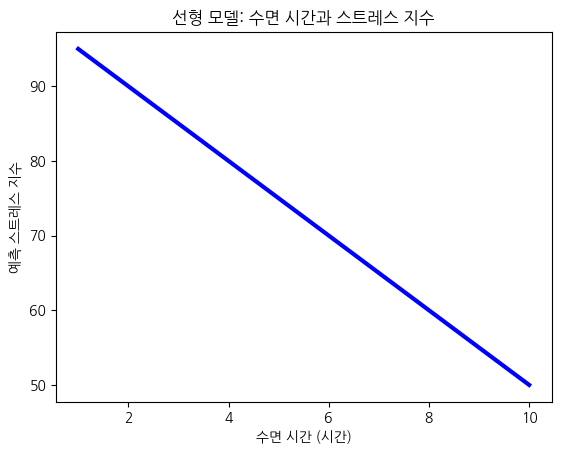

In [9]:
# 입력 데이터: 1시간부터 10시간까지 100개의 점으로 부드럽게 표현
sleep_hours = np.linspace(1, 10, 100)

# 선형 함수 정의: y = -5x + 100
def stress_linear_model(x):
    return -5 * x + 100

# 모델로 스트레스 지수 예측
stress_level = stress_linear_model(sleep_hours)

# 그래프 그리기
plt.plot(sleep_hours, stress_level, color='blue', linewidth=3)
plt.title('선형 모델: 수면 시간과 스트레스 지수')
plt.xlabel('수면 시간 (시간)')
plt.ylabel('예측 스트레스 지수')
plt.show()

##### **✍️ 문제**

'고강도 운동'이라는 변수가 추가되어, "수면 1시간당 스트레스 지수가 **8**씩 감소"하는 새로운 모델을 가정해 봅시다. 이 새로운 모델(`y = -8x + 100`)의 그래프를 기존 그래프에 빨간색 파선(`--`)으로 추가하여 두 모델을 비교해 보세요.

##### **✅ 정답**

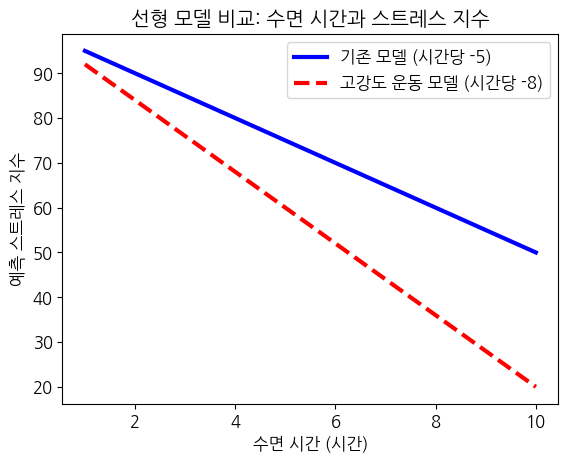

In [19]:
# TODO: 새로운 선형 함수 정의
sleep_hours = np.linspace(1, 10, 100)

def new_stress_linear_model(x):
    return -8 * x + 100

# TODO: 새로운 모델로 스트레스 지수 예측
new_stress_level = new_stress_linear_model(sleep_hours)

# 두 그래프 함께 그리기
plt.plot(sleep_hours, stress_level, color='blue', linewidth=3, label='기존 모델 (시간당 -5)')
plt.plot(sleep_hours, new_stress_level, color='red', linewidth=3, linestyle='--', label='고강도 운동 모델 (시간당 -8)')
plt.title('선형 모델 비교: 수면 시간과 스트레스 지수')
plt.xlabel('수면 시간 (시간)')
plt.ylabel('예측 스트레스 지수')
plt.legend() # label 옵션을 화면에 표시
plt.show()

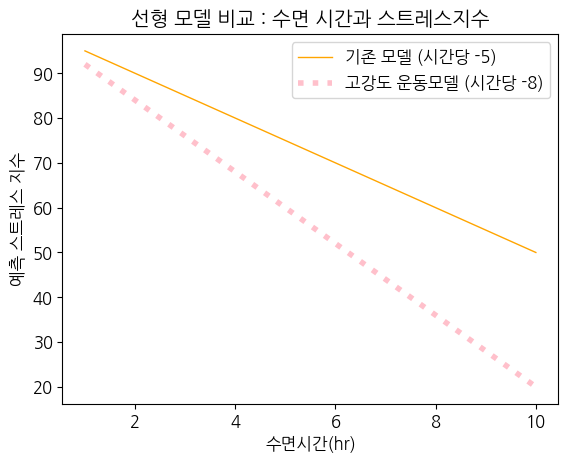

In [20]:
sleep_hours = np.linspace(1, 10, 100)

def new_stress_linear_modle(x):
    return -8*x + 100
new_stress_level = new_stress_linear_modle(sleep_hours)

plt.plot(sleep_hours, stress_level, color="orange", linewidth=1, label="기존 모델 (시간당 -5)")
plt.plot(sleep_hours, new_stress_level, color="pink", linewidth=4, linestyle=":", label="고강도 운동모델 (시간당 -8)")
plt.title("선형 모델 비교 : 수면 시간과 스트레스지수")
plt.xlabel("수면시간(hr)")
plt.ylabel("예측 스트레스 지수")
plt.legend()
plt.show()

-----

### **2. 지수 함수 (Exponential Function): 폭발적인 성장 관계**

  * **공식**: $y = e^x$
  * **그래프 모양**: 처음에는 완만하다가 어느 순간부터 **기하급수적으로 폭발하듯** 치솟는 곡선.
  * **헬스케어 예시**: **체내 박테리아 증식 속도**

[Image of an exponential function graph]

#### **💡 Insight & 그래프 해석**

그래프가 뒤로 갈수록 **수직에 가깝게 치솟는 것**이 핵심입니다. 이는 '성장률' 자체가 계속해서 증가하고 있음을 의미합니다. 헬스케어에서는 "시간이 조금만 더 지나도 상황이 걷잡을 수 없이 악화될 수 있다"는 긴급한 상황을 시각적으로 경고합니다. 따라서 **초기 단계의 개입**이 얼마나 중요한지 보여주는 그래프입니다.

#### **💻 파이썬 실습**

##### **🛠️ 사용 방법 및 주요 함수 안내**

  * **NumPy `np.exp(x)`**: 자연상수 $e$의 거듭제곱($e^x$) 값을 계산합니다. 배열을 입력하면 각 원소에 대해 $e^x$를 계산하여 반환합니다.

In [21]:
# e^1, e^2 값 계산
exp_values = np.exp([1, 2])
print(exp_values) # 출력: [2.71828183 7.3890561 ]

[2.71828183 7.3890561 ]


##### **예제: 시간에 따른 박테리아 수 증식 시각화**

0시간부터 5시간까지, 박테리아 수가 시간에 따라 지수적으로 증가하는 모델을 그려봅니다.

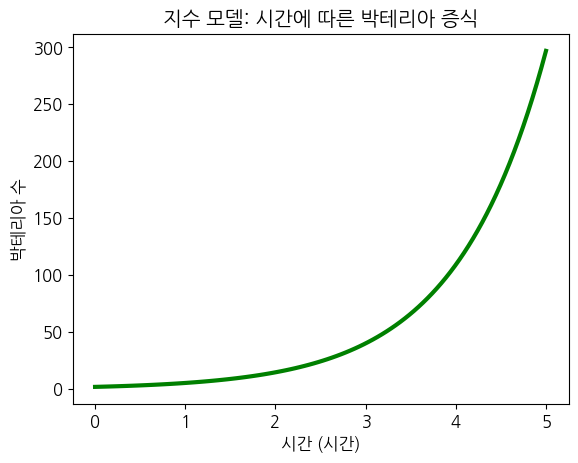

In [28]:
# 입력 데이터: 0시간부터 5시간까지
time = np.linspace(0, 5, 100)

# 지수 함수 정의
def bacteria_growth_model(t):
    # 2 * e^(t) -> 초기 2마리, 시간당 증식률
    return 2 * np.exp(t)

# 시간에 따른 박테리아 수 예측
bacteria_count = bacteria_growth_model(time)

# 그래프 그리기
plt.plot(time, bacteria_count, color='green', linewidth=3)
plt.title('지수 모델: 시간에 따른 박테리아 증식')
plt.xlabel('시간 (시간)')
plt.ylabel('박테리아 수')
plt.show()

##### **✍️ 문제**

영양분이 부족한 환경이라 **증식 속도가 더 느린** 박테리아를 모델링하려고 합니다. 기존 모델의 식 `y = 2 * e^t` 에서 지수 부분을 `t` 대신 `0.5 * t` 로 변경하여, 새로운 모델 `y = 2 * e^(0.5t)`의 그래프를 기존 그래프에 **주황색 파선**으로 추가해 비교해 보세요.

##### **✅ 정답**

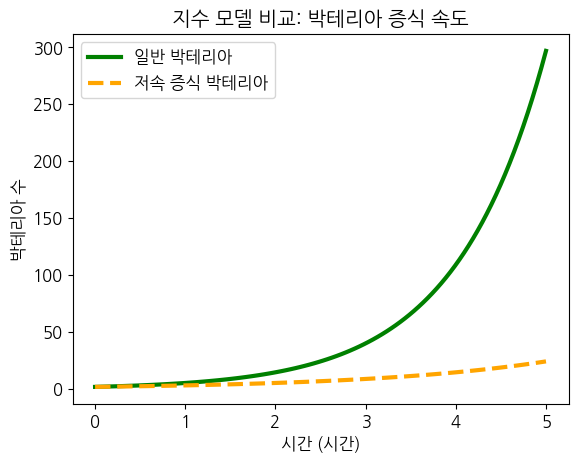

In [31]:
# TODO: 증식 속도가 느린 새로운 지수 함수 정의
time = np.linspace(0, 5, 100)

def bacteria_growth_model(t):
    return 2 * np.exp(0.5 * t)

# TODO: 새로운 모델로 박테리아 수 예측
slow_bacteria_count = bacteria_growth_model(time)

# 두 그래프 함께 그리기
plt.plot(time, bacteria_count, color='green', linewidth=3, label='일반 박테리아')
plt.plot(time, slow_bacteria_count, color='orange', linewidth=3, linestyle='--', label='저속 증식 박테리아')
plt.title('지수 모델 비교: 박테리아 증식 속도')
plt.xlabel('시간 (시간)')
plt.ylabel('박테리아 수')
plt.legend()
plt.show()

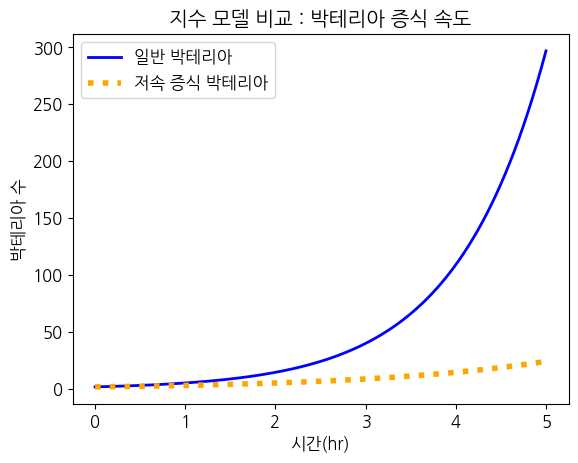

In [35]:
time = np.linspace(0,5,100)

def bacteria_growth_model(t):
    return 2* np.exp(0.5 * t)

slow_bacteria_count = bacteria_growth_model(time)

plt.plot(time, bacteria_count, color='blue', linewidth=2, label= '일반 박테리아')
plt.plot(time, slow_bacteria_count, color='orange', linewidth=4, linestyle=':', label='저속 증식 박테리아')
plt.title('지수 모델 비교 : 박테리아 증식 속도')
plt.xlabel('시간(hr)')
plt.ylabel('박테리아 수')
plt.legend()
plt.show()

-----

### **3. 로그 함수 (Logarithmic Function): 점점 둔화되는 성장 관계**

  * **공식**: $y = log(x)$
  * **그래프 모양**: 처음에는 빠르게 치솟다가, 점차 **성장세가 둔화되며 완만해지는** 곡선.
  * **헬스케어 예시**: **운동 횟수에 따른 근력 증가량**

[Image of a logarithmic function graph]

#### **💡 Insight & 그래프 해석**

그래프가 **오른쪽으로 갈수록 수평에 가까워지는 것**이 핵심입니다. 이는 '수확 체감의 법칙'을 시각적으로 보여줍니다. "초기 투입(노력)은 엄청난 효율을 보이지만, 일정 수준 이상부터는 많은 노력을 해도 얻는 것이 적다"는 의미입니다. 훈련 프로그램의 효율성을 평가하거나, 약물 효과의 포화점을 찾는 데 중요한 인사이트를 줍니다.

#### **💻 파이썬 실습**

##### **🛠️ 사용 방법 및 주요 함수 안내**

  * **NumPy `np.log(x)`**: 자연로그($log_e(x)$) 값을 계산합니다. 배열을 입력하면 각 원소에 대해 자연로그를 계산하여 반환합니다. **(입력값 x는 반드시 0보다 커야 합니다.)**

In [ ]:
# log(1), log(e), log(10) 값 계산
log_values = np.log([1, np.e, 10])
print(log_values) # 출력: [0.         1.         2.30258509]

##### **예제: 운동 횟수에 따른 근력 증가 시각화**

운동 횟수를 1회부터 100회까지 가정하고, 로그 함수를 이용해 근력 증가 패턴을 그려봅니다.

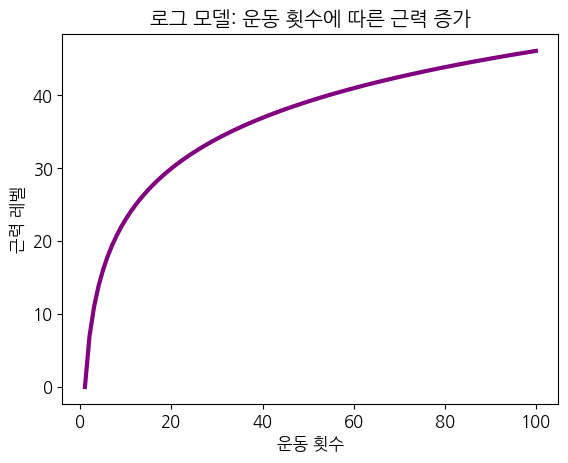

In [39]:
# 입력 데이터: 1회부터 100회까지의 운동 횟수 (로그 함수는 0을 입력받을 수 없음)
training_sessions = np.linspace(1, 100, 100)

# 로그 함수 정의
def strength_gain_model(sessions):
    # 10 * log(sessions) -> 기본 근력 0에서 시작, 훈련에 따라 증가
    return 10 * np.log(sessions)

# 운동 횟수에 따른 근력 예측
strength_level = strength_gain_model(training_sessions)

# 그래프 그리기
plt.plot(training_sessions, strength_level, color='purple', linewidth=3)
plt.title('로그 모델: 운동 횟수에 따른 근력 증가')
plt.xlabel('운동 횟수')
plt.ylabel('근력 레벨')
plt.show()

##### **✍️ 문제**

**유전적으로 재능이 뛰어나 초기 성장세가 더 가파른** 선수를 모델링하려고 합니다. 기존 모델 `y = 10 * log(x)`의 계수를 `20`으로 바꾸어, 새로운 모델 `y = 20 * log(x)`의 그래프를 기존 그래프에 **하늘색 파선**으로 추가하여 비교해 보세요.

##### **✅ 정답**

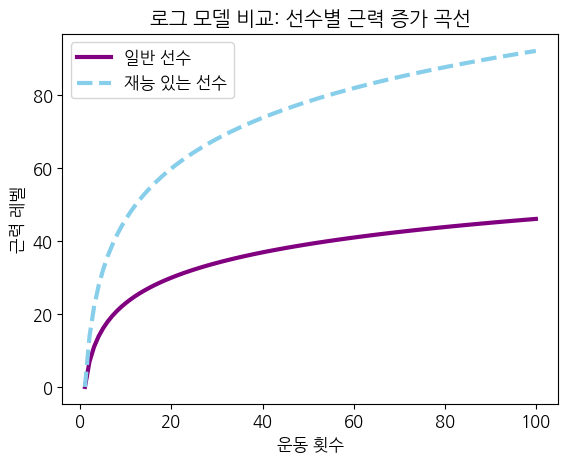

In [40]:
# TODO: 재능 있는 선수의 로그 함수 정의
def strong_strength_gain_model(sessions):
    return 20 * np.log(sessions)

# TODO: 새로운 모델로 근력 예측
strong_strength_level = strong_strength_gain_model(training_sessions)

# 두 그래프 함께 그리기
plt.plot(training_sessions, strength_level, color='purple', linewidth=3, label='일반 선수')
plt.plot(training_sessions, strong_strength_level, color='skyblue', linewidth=3, linestyle='--', label='재능 있는 선수')
plt.title('로그 모델 비교: 선수별 근력 증가 곡선')
plt.xlabel('운동 횟수')
plt.ylabel('근력 레벨')
plt.legend()
plt.show()

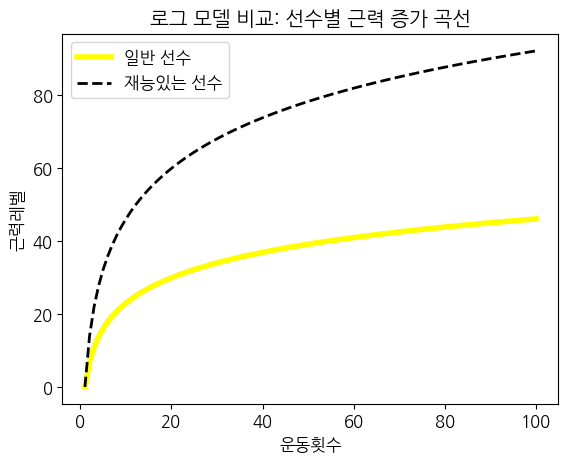

In [43]:
def s_strength_gain_model(sessions):
    return 20 * np.log(sessions)

s_strength_level = s_strength_gain_model(training_sessions)

plt.plot(training_sessions, strength_level, color="yellow", linewidth=4, label ="일반 선수")
plt.plot(training_sessions,s_strength_level, color="black", linewidth=2, linestyle = "--", label="재능있는 선수")
plt.title("로그 모델 비교: 선수별 근력 증가 곡선")
plt.xlabel("운동횟수")
plt.ylabel("근력레벨")
plt.legend()
plt.show()



```
# 코드로 형식 지정됨
```

-----

### **4. 시그모이드 함수 (Sigmoid Function): '예' 또는 '아니오'의 확률**

  * **공식**: $y = 1 / (1 + e^{-x})$
  * **그래프 모양**: 알파벳 'S' 형태의 곡선으로, **결코 0 아래로 내려가거나 1 위로 올라가지 않습니다.**
  * **헬스케어 예시**: **질병 진단 모델의 최종 판단**

[Image of a sigmoid function graph]

#### **💡 Insight & 그래프 해석**

그래프가 **0과 1 사이에 갇혀 있는 것**이 핵심입니다. 이는 불확실한 예측 점수를 명확한 '확률'로 바꾸어주는 변환 장치임을 의미합니다. 그래프가 급격히 꺾이는 **중심(x=0) 부분**이 AI의 '결정 경계(Decision Boundary)'입니다. 이 근처에서는 위험도 점수가 조금만 변해도 확률이 크게 바뀌므로, 모델이 '긍정'과 '부정' 사이에서 가장 민감하게 반응하는 구간임을 알 수 있습니다.

#### **💻 파이썬 실습**

##### **🛠️ 사용 방법 및 주요 함수 안내**

  * **Matplotlib `plt.axhline(y, color, linestyle)`**: `y` 위치에 수평선을 그립니다. 그래프의 특정 기준선을 표시할 때 유용합니다.

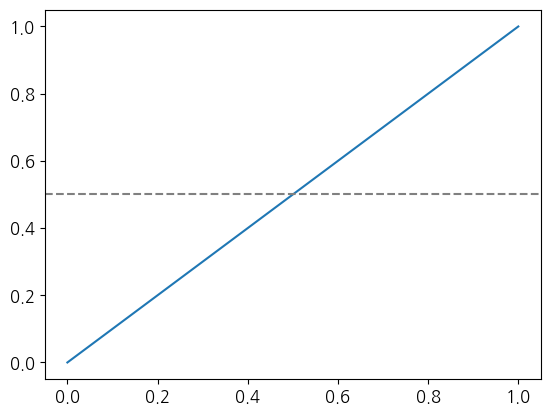

In [44]:
plt.plot([0, 1], [0, 1]) # 샘플 플롯
# y=0.5 위치에 회색 점선으로 수평선 그리기
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.show()

##### **예제: 위험도 점수를 질병 확률로 변환하기**

\-10부터 10까지의 가상 '위험도 점수'를 시그모이드 함수에 통과시켜 0과 1 사이의 확률값으로 변환하고 그래프를 그려봅니다.

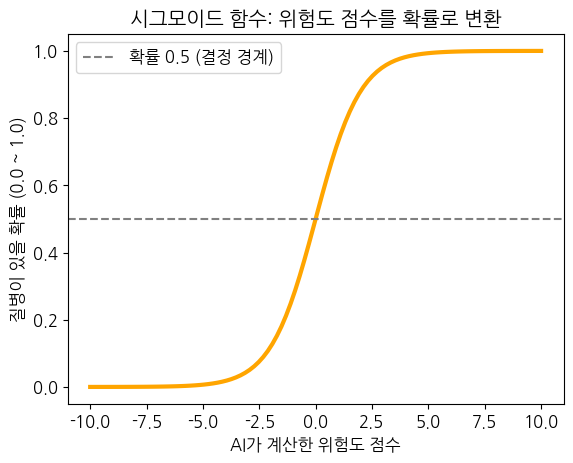

In [47]:
# 입력 데이터: -10부터 10까지의 위험도 점수
risk_scores = np.linspace(-10, 10, 100)

# 시그모이드 함수 정의
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 위험도 점수를 확률로 변환
probabilities = sigmoid(risk_scores)

# 그래프 그리기
plt.plot(risk_scores, probabilities, color='orange', linewidth=3)
plt.axhline(y=0.5, color='grey', linestyle='--', label='확률 0.5 (결정 경계)') # 0.5 기준선 추가
plt.title('시그모이드 함수: 위험도 점수를 확률로 변환')
plt.xlabel('AI가 계산한 위험도 점수')
plt.ylabel('질병이 있을 확률 (0.0 ~ 1.0)')
plt.legend()
plt.show()

##### **✍️ 문제**

환자 3명의 위험도 점수가 각각 `-7`, `0.5`, `4.8`로 계산되었습니다. 이 점수들을 우리가 정의한 `sigmoid` 함수를 사용하여 **실제 확률값으로 변환**하고, 각 확률이 어떤 의미인지 해석해 보세요.

##### **✅ 정답**

In [55]:
# TODO: 환자들의 위험도 점수
patient_scores = np.array([-7, 0.5 , 4.8])

    
# TODO: 각 점수를 확률로 변환
probabilities = sigmoid(patient_scores)

# TODO: 결과 출력 (예: 위험도 점수 0.0  ->  질병 확률: 0.00%)
print(f'첫번째 환자의 위험도 점수:{patient_scores[0]}  ->  질병 확률: {probabilities[0]*100:.2f}%')
print(f'두번째 환자의 위험도 점수:{patient_scores[1]}  ->  질병 확률: {probabilities[1]*100:.2f}%')
print(f'세번째 환자의 위험도 점수:{patient_scores[2]}  ->  질병 확률: {probabilities[2]*100:.2f}%')

첫번째 환자의 위험도 점수:-7.0  ->  질병 확률: 0.09%
두번째 환자의 위험도 점수:0.5  ->  질병 확률: 62.25%
세번째 환자의 위험도 점수:4.8  ->  질병 확률: 99.18%


In [ ]:
#첫번째 환자는 반환값인 y값이 최솟값과 가까워지는 x값을 가지고 있으며 질병에 걸릴 확률이 매우 낮음 (음성)
#두번째 환자는 결정 경계에 주변에 있는 환자로 점수가 조금만 변해도 큰 영향을 받음
#세번째 환자는 반환값인 y값이 최댓값과 가까워지는 x값을 가지고 있으며 질병에 걸릴 확률이 매우 높음 (양성)